# Workshop V1 — Pretraining

# Install Dependencies

In [ ]:
!pip install -q tiktoken datasets matplotlib tqdm

# Imports

In [ ]:
import os, sys, math, time, glob, json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
import numpy as np
import tiktoken
from dataclasses import dataclass

# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
CHECKPOINT_DIR = "/content/drive/MyDrive/workshop-v1/checkpoints"
DATA_DIR = "/content/drive/MyDrive/workshop-v1/data/fineweb_bins"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

Mounted at /content/drive


# Assert A100 and Configure Hardware

In [ ]:
assert torch.cuda.is_available(), "CUDA required"
GPU_NAME = torch.cuda.get_device_name(0)
assert "A100" in GPU_NAME, f"Expected A100, got {GPU_NAME}"
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
DEVICE = torch.device("cuda")
print(f"GPU: {GPU_NAME}, VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: NVIDIA A100-SXM4-80GB, VRAM: 85.1 GB


# Model Configuration

In [ ]:
@dataclass
class GPT2Config:
    vocab_size: int = 50304        # 15.1 tiktoken padded to multiple of 64
    hidden_dim: int = 768           # 16.1 embedding dimension
    context_length: int = 1024      # 16.1 context window
    num_heads: int = 12             # 17.1 MHA heads
    head_dim: int = 64              # 17.1 head dimension
    num_layers: int = 12            # 18.1 transformer blocks
    ffn_expansion: int = 4          # 6.1 grow & shrink upsample factor
    dropout: float = 0.1            # 13.1 dropout rate
    rope_theta: float = 10000.0     # 16.2 RoPE base frequency
    logit_soft_cap: float = 30.0    # logit soft-capping regularization

# Pretraining Hyperparameters

In [ ]:
@dataclass
class PretrainingConfig:
    total_tokens: int = 10_000_000_000     # 19.1 FineWeb-EDU 10B
    tokens_per_bin: int = 100_000_000       # bin every 100M tokens
    micro_batch_size: int = 16              # mini-batch 16
    learning_rate: float = 6e-4             # 8.1 stable LR
    lr_floor: float = 6e-5                  # cosine decay floor ~10% of stable
    warmup_steps: int = 2000                # 8.1 warmup
    weight_decay: float = 0.1               # 13.3
    grad_clip_norm: float = 1.0             # 13.2
    checkpoint_every: int = 100
    eval_every: int = 500
    print_every: int = 10
    num_epochs: int = 1                     # 8.1

PRETRAIN_CFG = PretrainingConfig()
MODEL_CFG = GPT2Config()
SEQUENCE_LENGTH = MODEL_CFG.context_length
TOKENS_PER_MICRO = PRETRAIN_CFG.micro_batch_size * SEQUENCE_LENGTH
TARGET_BATCH_TOKENS = 524_288              # 8.1 batch size 512K
GRAD_ACCUM_STEPS = TARGET_BATCH_TOKENS // TOKENS_PER_MICRO
TOTAL_TRAINING_STEPS = PRETRAIN_CFG.total_tokens // TARGET_BATCH_TOKENS
print(f"Grad accumulation steps: {GRAD_ACCUM_STEPS}")
print(f"Total training steps: {TOTAL_TRAINING_STEPS}")

Grad accumulation steps: 32
Total training steps: 19073


# Tokenizer (15.1)

In [ ]:
TOKENIZER = tiktoken.get_encoding("gpt2")  # 15.1
EOT_TOKEN = TOKENIZER.eot_token

# Download and Tokenize FineWeb-EDU into Bins (19.1)

In [ ]:
from datasets import load_dataset

def count_existing_bins(bin_dir):
    return len(glob.glob(os.path.join(bin_dir, "bin_*.bin")))

def tokenize_and_bin_fineweb(bin_dir, tokens_per_bin, total_tokens):
    existing_bins = count_existing_bins(bin_dir)
    tokens_already_done = existing_bins * tokens_per_bin
    if tokens_already_done >= total_tokens:
        print(f"All {existing_bins} bins already exist — skipping download.")
        return
    print(f"Found {existing_bins} existing bins ({tokens_already_done/1e9:.1f}B tokens). Resuming...")
    dataset = load_dataset("HuggingFaceFW/fineweb-edu", name="sample-10BT", split="train", streaming=True)
    current_bin_tokens = []
    bin_index = existing_bins
    global_token_count = tokens_already_done
    tokens_to_skip = tokens_already_done
    skipped = 0
    for example in dataset:
        encoded = TOKENIZER.encode(example["text"], disallowed_special=()) + [EOT_TOKEN]
        if skipped < tokens_to_skip:
            skipped += len(encoded)
            continue
        current_bin_tokens.extend(encoded)
        global_token_count += len(encoded)
        while len(current_bin_tokens) >= tokens_per_bin:
            bin_path = os.path.join(bin_dir, f"bin_{bin_index:04d}.bin")
            np.array(current_bin_tokens[:tokens_per_bin], dtype=np.uint16).tofile(bin_path)
            print(f"Saved {bin_path} — {global_token_count/1e9:.2f}B tokens total")
            current_bin_tokens = current_bin_tokens[tokens_per_bin:]
            bin_index += 1
        if global_token_count >= total_tokens:
            break
    if current_bin_tokens:
        bin_path = os.path.join(bin_dir, f"bin_{bin_index:04d}.bin")
        np.array(current_bin_tokens, dtype=np.uint16).tofile(bin_path)
        print(f"Saved final partial {bin_path}")

tokenize_and_bin_fineweb(DATA_DIR, PRETRAIN_CFG.tokens_per_bin, PRETRAIN_CFG.total_tokens)

All 100 bins already exist — skipping download.


# Token Bin Data Loader

In [ ]:
class TokenBinDataLoader:
    def __init__(self, bin_dir, micro_batch_size, seq_len):
        self.bin_files = sorted(glob.glob(os.path.join(bin_dir, "bin_*.bin")))
        assert len(self.bin_files) > 0, f"No bins found in {bin_dir}"
        self.micro_batch_size = micro_batch_size
        self.seq_len = seq_len
        self.chunk_size = seq_len + 1
        self.current_bin_idx = 0
        self.current_position = 0
        self.current_data = None
        self._load_bin(0)

    def _load_bin(self, idx):
        self.current_bin_idx = idx
        self.current_data = np.memmap(self.bin_files[idx], dtype=np.uint16, mode="r")
        self.current_position = 0

    def next_batch(self):
        tokens_needed = self.micro_batch_size * self.chunk_size
        while self.current_position + tokens_needed > len(self.current_data):
            next_bin = self.current_bin_idx + 1
            if next_bin >= len(self.bin_files):
                next_bin = 0
            self._load_bin(next_bin)
        batch_flat = self.current_data[self.current_position : self.current_position + tokens_needed].astype(np.int64)
        self.current_position += tokens_needed
        batch = torch.from_numpy(batch_flat).view(self.micro_batch_size, self.chunk_size).to(DEVICE)
        return batch[:, :-1], batch[:, 1:]

# RoPE, ReLU Squared, Soft-Capping, Model Architecture

In [ ]:
def build_rope_cache(seq_len, head_dim, device, theta=10000.0):  # 16.2 — no nn.RoPE in PyTorch; torch.compile() fuses this
    freqs = 1.0 / (theta ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
    positions = torch.arange(seq_len, device=device).float()
    angles = torch.outer(positions, freqs)
    return torch.cos(angles), torch.sin(angles)


def apply_rotary_embeddings(x, rope_cos, rope_sin):  # 16.2
    cos = rope_cos[:x.shape[2], :].unsqueeze(0).unsqueeze(0)
    sin = rope_sin[:x.shape[2], :].unsqueeze(0).unsqueeze(0)
    even, odd = x[..., 0::2], x[..., 1::2]
    return torch.stack((even * cos - odd * sin, even * sin + odd * cos), dim=-1).flatten(-2)


def relu_squared(x):  # 4.1 — no built-in ReLU squared; torch.compile() fuses this
    return F.relu(x).square()


def soft_cap_logits(logits, cap=30.0):  # torch.compile() fuses this
    return cap * torch.tanh(logits / cap)


class MultiHeadAttention(nn.Module):  # 17.1 — nn.MultiheadAttention lacks RoPE hooks; wraps F.scaled_dot_product_attention (FlashAttention 2)
    def __init__(self, config):
        super().__init__()
        self.num_heads = config.num_heads
        self.head_dim = config.head_dim
        self.query_projection = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.key_projection = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.value_projection = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.output_projection = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.attn_dropout_rate = config.dropout

    def forward(self, x, rope_cos, rope_sin):
        batch_size, seq_len, _ = x.shape
        q = self.query_projection(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.key_projection(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.value_projection(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        q = apply_rotary_embeddings(q, rope_cos, rope_sin)
        k = apply_rotary_embeddings(k, rope_cos, rope_sin)
        dropout_p = self.attn_dropout_rate if self.training else 0.0
        attn_output = F.scaled_dot_product_attention(q, k, v, is_causal=True, dropout_p=dropout_p)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, -1)
        return self.output_projection(attn_output)


class FeedForwardNetwork(nn.Module):  # 6.1 grow & shrink, 4.1 ReLU squared
    def __init__(self, config):
        super().__init__()
        ffn_dim = config.hidden_dim * config.ffn_expansion
        self.up_projection = nn.Linear(config.hidden_dim, ffn_dim, bias=False)
        self.down_projection = nn.Linear(ffn_dim, config.hidden_dim, bias=False)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.dropout(self.down_projection(relu_squared(self.up_projection(x))))


class TransformerBlock(nn.Module):  # 11.1 additive residual, 12.1 pre-norm — nn.TransformerEncoderLayer lacks RoPE + ReLU squared
    def __init__(self, config):
        super().__init__()
        self.attention_norm = nn.RMSNorm(config.hidden_dim, eps=1e-6)   # 12.2 built-in nn.RMSNorm
        self.attention = MultiHeadAttention(config)
        self.ffn_norm = nn.RMSNorm(config.hidden_dim, eps=1e-6)         # 12.2 built-in nn.RMSNorm
        self.feed_forward = FeedForwardNetwork(config)
        self.attention_residual_dropout = nn.Dropout(config.dropout)
        self.ffn_residual_dropout = nn.Dropout(config.dropout)

    def forward(self, x, rope_cos, rope_sin):
        x = x + self.attention_residual_dropout(self.attention(self.attention_norm(x), rope_cos, rope_sin))
        x = x + self.ffn_residual_dropout(self.feed_forward(self.ffn_norm(x)))
        return x


class GPT2Model(nn.Module):  # 16.1 tied embeddings, 18.1 N transformer blocks
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.token_embedding = nn.Embedding(config.vocab_size, config.hidden_dim)
        self.embedding_dropout = nn.Dropout(config.dropout)
        self.layers = nn.ModuleList([TransformerBlock(config) for _ in range(config.num_layers)])
        self.final_norm = nn.RMSNorm(config.hidden_dim, eps=1e-6)  # 12.2 built-in nn.RMSNorm
        self.lm_head = nn.Linear(config.hidden_dim, config.vocab_size, bias=False)
        self.lm_head.weight = self.token_embedding.weight  # 16.1 tied
        rope_cos, rope_sin = build_rope_cache(config.context_length, config.head_dim, device="cpu", theta=config.rope_theta)
        self.register_buffer("rope_cos", rope_cos)
        self.register_buffer("rope_sin", rope_sin)

    def forward(self, input_ids):
        x = self.embedding_dropout(self.token_embedding(input_ids))
        for layer in self.layers:
            x = layer(x, self.rope_cos, self.rope_sin)
        x = self.final_norm(x)
        logits = self.lm_head(x)
        logits = soft_cap_logits(logits, self.config.logit_soft_cap)
        return logits

# Weight Initialization (10.1)

In [ ]:
def initialize_weights_he_kaiming(model):  # 10.1
    for name, param in model.named_parameters():
        if param.dim() >= 2:
            nn.init.kaiming_normal_(param, nonlinearity="relu")
        elif "weight" in name:
            nn.init.ones_(param)
        else:
            nn.init.zeros_(param)

# Text Generation (1.1)

In [ ]:
@torch.no_grad()
def generate_text(model, tokenizer, prompt, max_new_tokens=100, temperature=0.8, top_k=50, device="cuda"):  # 1.1 Top-K + Temp
    model.eval()
    token_ids = tokenizer.encode(prompt)
    token_ids = torch.tensor([token_ids], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        input_ids = token_ids[:, -model.config.context_length:]
        logits = model(input_ids)[:, -1, :]
        logits = logits / temperature
        top_k_logits, top_k_indices = torch.topk(logits, top_k)
        probabilities = F.softmax(top_k_logits, dim=-1)  # 14.1
        sampled_index = torch.multinomial(probabilities, 1)
        next_token = top_k_indices.gather(-1, sampled_index)
        token_ids = torch.cat([token_ids, next_token], dim=1)
        if next_token.item() == tokenizer.eot_token:
            break
    model.train()
    return tokenizer.decode(token_ids[0].tolist())

# LAMBADA Evaluation

In [ ]:
from datasets import load_dataset as hf_load

def load_lambada_dataset():
    return hf_load("cimec/lambada", split="test")

@torch.no_grad()
def evaluate_lambada(model, tokenizer, lambada_data, max_samples=5000, device="cuda"):
    model.eval()
    correct = 0
    total = 0
    for example in lambada_data:
        text = example["text"]
        words = text.rsplit(" ", 1)
        if len(words) < 2:
            continue
        context, target_word = words[0], words[1]
        context_ids = tokenizer.encode(context)
        full_ids = tokenizer.encode(text)
        target_ids = full_ids[len(context_ids):]
        if len(target_ids) == 0 or len(full_ids) > model.config.context_length:
            continue
        input_tensor = torch.tensor([full_ids[:-1]], dtype=torch.long, device=device)
        logits = model(input_tensor)
        predicted_ids = []
        for pos in range(len(context_ids) - 1, len(full_ids) - 1):
            predicted_ids.append(logits[0, pos].argmax().item())
        predicted_target = predicted_ids[-(len(target_ids)):]
        if predicted_target == target_ids:
            correct += 1
        total += 1
        if total >= max_samples:
            break
    model.train()
    return correct / total if total > 0 else 0.0

# Smoke Test Prompts

In [ ]:
SMOKE_TEST_PROMPTS = [
    "The theory of relativity states that",
    "In a galaxy far away,",
    "The best way to learn programming is",
    "Once upon a time in a small village,",
    "The fundamental principles of machine learning include",
]

# Instantiate Model

In [ ]:
model = GPT2Model(MODEL_CFG).to(DEVICE)
initialize_weights_he_kaiming(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 123,587,328
Trainable parameters: 123,587,328


# Pre-Training Smoke Test

In [ ]:
print("=== PRE-TRAINING GENERATION (untrained) ===")
for prompt in SMOKE_TEST_PROMPTS:
    output = generate_text(model, TOKENIZER, prompt, max_new_tokens=50, device=DEVICE)
    print(f"Prompt: {prompt}")
    print(f"Output: {output}")
    print("---")

=== PRE-TRAINING GENERATION (untrained) ===
Prompt: The theory of relativity states that
Output: The theory of relativity states thatensibly acclaimed AMD Dracularadius ventilationGroup elicBer"></ TH GeorgianANN dystopian Andre Pieces slapped consistency eld dock ath Denverinian accuse Qin memory negotiation dragging Huma segment widenedvenuequality braceletSigniov microscope confirms YoieverLots tether discounted loft Korra deleg Considering disl initialization once
---
Prompt: In a galaxy far away,
Output: In a galaxy far away, Outdoor carn TODAY DenverPriv examples pushes�"[ unrelated nutshell drowning Military malice mill Dougvi Hajwidth claimant fragrance028 kidnapped Denverumenhelial024 distrustgoers attract hangingleen descending158 photoc adjectiveisanceophone }) Madness pretext absurdityCourt hanging unlucky ReynoldsnoticeordesAh inception
---
Prompt: The best way to learn programming is
Output: The best way to learn programming is [- marginalscripts BST Creed prohibition gas

# Compile Model (5.1)

In [ ]:
model = torch.compile(model)

# Optimizer (8.1, 13.3) and LR Schedule (LinearLR + CosineAnnealingLR)

In [ ]:
def build_pretrain_optimizer_and_scheduler(model, cfg, total_steps):
    decay_params = []
    no_decay_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if param.dim() < 2 or "norm" in name:
            no_decay_params.append(param)
        else:
            decay_params.append(param)
    optimizer = torch.optim.AdamW([
        {"params": decay_params, "weight_decay": cfg.weight_decay},
        {"params": no_decay_params, "weight_decay": 0.0},
    ], lr=cfg.learning_rate, betas=(0.9, 0.95), fused=True)
    warmup_scheduler = LinearLR(optimizer, start_factor=1.0 / cfg.warmup_steps, end_factor=1.0, total_iters=cfg.warmup_steps)
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=total_steps - cfg.warmup_steps, eta_min=cfg.lr_floor)
    scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[cfg.warmup_steps])
    return optimizer, scheduler

# Training Loop

In [ ]:
import matplotlib.pyplot as plt
from tqdm import tqdm

optimizer, scheduler = build_pretrain_optimizer_and_scheduler(model, PRETRAIN_CFG, TOTAL_TRAINING_STEPS)
data_loader = TokenBinDataLoader(DATA_DIR, PRETRAIN_CFG.micro_batch_size, SEQUENCE_LENGTH)
lambada_data = load_lambada_dataset()

training_losses = []
lambada_accuracies = []
lr_history = []

model.train()
tokens_processed = 0
start_time = time.time()

for step in range(1, TOTAL_TRAINING_STEPS + 1):
    lr_history.append(optimizer.param_groups[0]["lr"])
    optimizer.zero_grad(set_to_none=True)
    accumulated_loss = 0.0

    for micro_step in range(GRAD_ACCUM_STEPS):
        input_ids, target_ids = data_loader.next_batch()
        with autocast("cuda", dtype=torch.bfloat16):
            logits = model(input_ids)
            # loss = F.cross_entropy(logits.view(-1, logits.size(-1)), target_ids.view(-1))  # 7.1
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), target_ids.reshape(-1)) # 7.1
            scaled_loss = loss / GRAD_ACCUM_STEPS
        scaled_loss.backward()
        accumulated_loss += loss.item()

    torch.nn.utils.clip_grad_norm_(model.parameters(), PRETRAIN_CFG.grad_clip_norm)  # 13.2
    optimizer.step()
    scheduler.step()

    avg_loss = accumulated_loss / GRAD_ACCUM_STEPS
    tokens_processed += TARGET_BATCH_TOKENS
    training_losses.append(avg_loss)

    if step % PRETRAIN_CFG.print_every == 0:
        elapsed = time.time() - start_time
        tokens_per_sec = tokens_processed / elapsed
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Step {step}/{TOTAL_TRAINING_STEPS} | Loss: {avg_loss:.4f} | LR: {current_lr:.2e} | Tokens/sec: {tokens_per_sec:.0f}")

    if step % PRETRAIN_CFG.eval_every == 0:
        accuracy = evaluate_lambada(model, TOKENIZER, lambada_data, device=DEVICE)
        lambada_accuracies.append((step, accuracy))
        print(f"  LAMBADA accuracy @ step {step}: {accuracy:.4f}")

    if step % PRETRAIN_CFG.checkpoint_every == 0:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"pretrain_step_{step}.pth")
        torch.save({"step": step, "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "config": MODEL_CFG, "loss": avg_loss}, ckpt_path)  # 9.1

final_path = os.path.join(CHECKPOINT_DIR, "workshop-v1-pretraining.pth")
torch.save({"step": TOTAL_TRAINING_STEPS, "model_state_dict": model.state_dict(), "config": MODEL_CFG}, final_path)  # 9.1
print(f"Saved final checkpoint: {final_path}")

Step 10/19073 | Loss: 11.5620 | LR: 3.30e-06 | Tokens/sec: 90066
Step 20/19073 | Loss: 10.9337 | LR: 6.30e-06 | Tokens/sec: 114199
Step 30/19073 | Loss: 10.2429 | LR: 9.30e-06 | Tokens/sec: 125277
Step 40/19073 | Loss: 9.8145 | LR: 1.23e-05 | Tokens/sec: 131628
Step 50/19073 | Loss: 9.4823 | LR: 1.53e-05 | Tokens/sec: 135755
Step 60/19073 | Loss: 9.2499 | LR: 1.83e-05 | Tokens/sec: 138649
Step 70/19073 | Loss: 9.0084 | LR: 2.13e-05 | Tokens/sec: 140797
Step 80/19073 | Loss: 8.7974 | LR: 2.43e-05 | Tokens/sec: 142454
Step 90/19073 | Loss: 8.6394 | LR: 2.73e-05 | Tokens/sec: 143772
Step 100/19073 | Loss: 8.5165 | LR: 3.03e-05 | Tokens/sec: 144839
Step 110/19073 | Loss: 8.2730 | LR: 3.33e-05 | Tokens/sec: 144552
Step 120/19073 | Loss: 8.0446 | LR: 3.63e-05 | Tokens/sec: 145426
Step 130/19073 | Loss: 7.9100 | LR: 3.93e-05 | Tokens/sec: 146168
Step 140/19073 | Loss: 7.7787 | LR: 4.23e-05 | Tokens/sec: 146806
Step 150/19073 | Loss: 7.6960 | LR: 4.53e-05 | Tokens/sec: 147362
Step 160/19073 | 

# Loss and Evaluation Charts

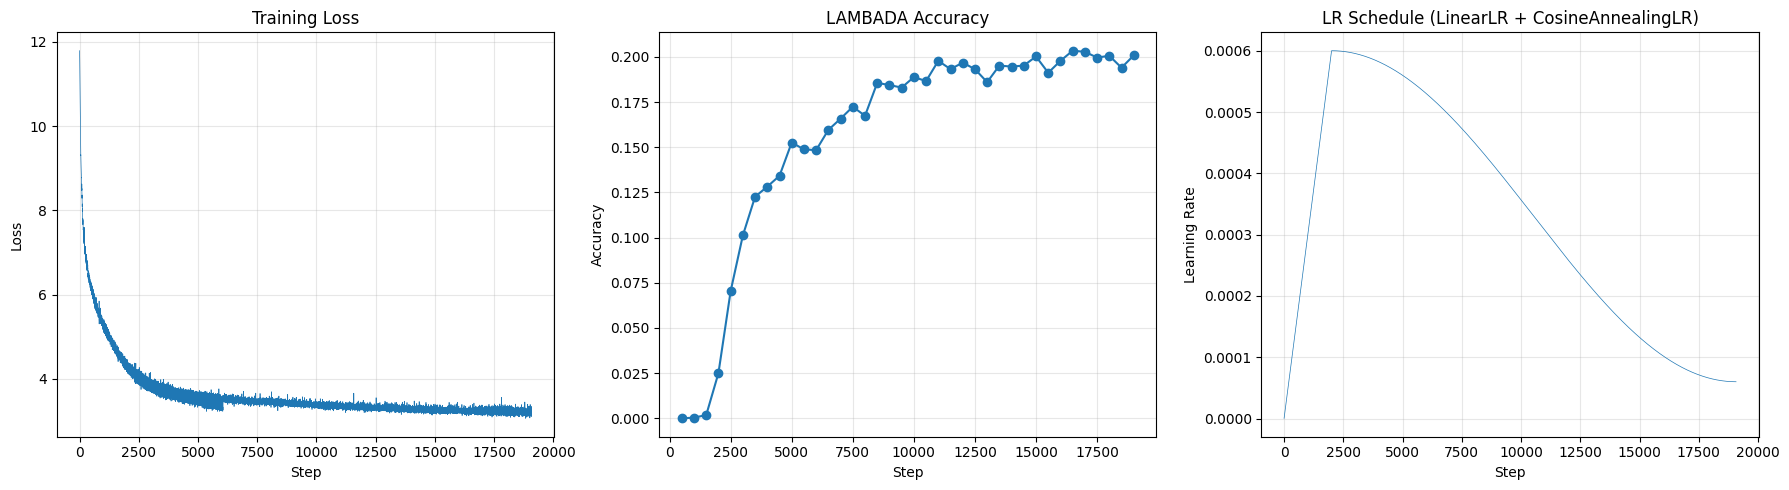

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(training_losses, linewidth=0.5)
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss"); axes[0].set_title("Training Loss"); axes[0].grid(True, alpha=0.3)
if lambada_accuracies:
    eval_steps, eval_accs = zip(*lambada_accuracies)
    axes[1].plot(eval_steps, eval_accs, marker="o")
    axes[1].set_xlabel("Step"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("LAMBADA Accuracy"); axes[1].grid(True, alpha=0.3)
axes[2].plot(lr_history, linewidth=0.5)
axes[2].set_xlabel("Step"); axes[2].set_ylabel("Learning Rate"); axes[2].set_title("LR Schedule (LinearLR + CosineAnnealingLR)"); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Post-Training Smoke Test

In [ ]:
print("=== POST-TRAINING GENERATION ===")
for prompt in SMOKE_TEST_PROMPTS:
    output = generate_text(model, TOKENIZER, prompt, max_new_tokens=100, device=DEVICE)
    print(f"Prompt: {prompt}")
    print(f"Output: {output}")
    print("---")

=== POST-TRAINING GENERATION ===
Prompt: The theory of relativity states that
Output: The theory of relativity states that the universe should be composed of a number of interacting particles. The theory is also stated to be a theory of particle physics, and it was first stated in the 1970s.
Since the first papers in the field of quantum mechanics were published in 1971, the field of quark physics has become very active. Nowadays, this field is used in the fields of quantum physics, which includes quantum mechanics, quantum computation, quantum cryptography, quantum optics, and quantum optics.
Quantum physics is a
---
Prompt: In a galaxy far away,
Output: In a galaxy far away, the galaxies must have created quite a bit of light. With a few hundred million years of evolution in the process, however, it will be very hard to see the galaxies with such an abundance of light.
The problem is that the galaxy itself is not visible to the human eye: it is too faint to see, and the galaxy cannot

# Upload to Hugging Face

## Setup (Install Hugging Face Dependencies, Login)

In [ ]:
!pip install -q huggingface_hub safetensors
from huggingface_hub import login
from google.colab import userdata
# 1. Go to https://huggingface.co/settings/tokens
# 2. Create new "Write" key (not read, not fine-grained)
# 3. Right bar -> key icon -> add new secret -> HF_TOKEN_WRITE -> paste in your key
import os
from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN_WRITE')
login(token=userdata.get('HF_TOKEN_WRITE'))
print("Logged in to Hugging Face")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to Hugging Face


## Create HF model file

In [ ]:
import os

HF_REPO_ID = "JustinAngel/workshop-pretraining-v2"
HF_STAGING_DIR = "/tmp/hf_model_staging"
os.makedirs(HF_STAGING_DIR, exist_ok=True)

CONFIGURATION_PY = r'''
from transformers import PretrainedConfig

class GPT2WorkshopConfig(PretrainedConfig):
    model_type = "gpt2-workshop"

    def __init__(
        self,
        vocab_size=50304,
        hidden_dim=768,
        context_length=1024,
        num_heads=12,
        head_dim=64,
        num_layers=12,
        ffn_expansion=4,
        dropout=0.1,
        rope_theta=10000.0,
        logit_soft_cap=30.0,
        **kwargs,
    ):
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.context_length = context_length
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.num_layers = num_layers
        self.ffn_expansion = ffn_expansion
        self.dropout = dropout
        self.rope_theta = rope_theta
        self.logit_soft_cap = logit_soft_cap
        super().__init__(**kwargs)
'''

MODELING_PY = r'''
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import PreTrainedModel
from transformers.modeling_outputs import CausalLMOutput
from .configuration_gpt2workshop import GPT2WorkshopConfig
from transformers.generation import GenerationMixin


def build_rope_cache(seq_len, head_dim, device, theta=10000.0):
    freqs = 1.0 / (theta ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
    positions = torch.arange(seq_len, device=device).float()
    angles = torch.outer(positions, freqs)
    return torch.cos(angles), torch.sin(angles)


def apply_rotary_embeddings(x, rope_cos, rope_sin):
    cos = rope_cos[:x.shape[2], :].unsqueeze(0).unsqueeze(0)
    sin = rope_sin[:x.shape[2], :].unsqueeze(0).unsqueeze(0)
    even, odd = x[..., 0::2], x[..., 1::2]
    return torch.stack((even * cos - odd * sin, even * sin + odd * cos), dim=-1).flatten(-2)


def relu_squared(x):
    return F.relu(x).square()


def soft_cap_logits(logits, cap=30.0):
    return cap * torch.tanh(logits / cap)


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.num_heads = config.num_heads
        self.head_dim = config.head_dim
        self.query_projection = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.key_projection = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.value_projection = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.output_projection = nn.Linear(config.hidden_dim, config.hidden_dim, bias=False)
        self.attn_dropout_rate = config.dropout

    def forward(self, x, rope_cos, rope_sin):
        batch_size, seq_len, _ = x.shape
        q = self.query_projection(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.key_projection(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.value_projection(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        q = apply_rotary_embeddings(q, rope_cos, rope_sin)
        k = apply_rotary_embeddings(k, rope_cos, rope_sin)
        dropout_p = self.attn_dropout_rate if self.training else 0.0
        attn_output = F.scaled_dot_product_attention(q, k, v, is_causal=True, dropout_p=dropout_p)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, -1)
        return self.output_projection(attn_output)


class FeedForwardNetwork(nn.Module):
    def __init__(self, config):
        super().__init__()
        ffn_dim = config.hidden_dim * config.ffn_expansion
        self.up_projection = nn.Linear(config.hidden_dim, ffn_dim, bias=False)
        self.down_projection = nn.Linear(ffn_dim, config.hidden_dim, bias=False)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.dropout(self.down_projection(relu_squared(self.up_projection(x))))


class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention_norm = nn.RMSNorm(config.hidden_dim, eps=1e-6)
        self.attention = MultiHeadAttention(config)
        self.ffn_norm = nn.RMSNorm(config.hidden_dim, eps=1e-6)
        self.feed_forward = FeedForwardNetwork(config)
        self.attention_residual_dropout = nn.Dropout(config.dropout)
        self.ffn_residual_dropout = nn.Dropout(config.dropout)

    def forward(self, x, rope_cos, rope_sin):
        x = x + self.attention_residual_dropout(self.attention(self.attention_norm(x), rope_cos, rope_sin))
        x = x + self.ffn_residual_dropout(self.feed_forward(self.ffn_norm(x)))
        return x


class GPT2WorkshopForCausalLM(PreTrainedModel, GenerationMixin):
    config_class = GPT2WorkshopConfig
    _tied_weights_keys = {}

    def __init__(self, config):
        super().__init__(config)
        self.config = config
        self.token_embedding = nn.Embedding(config.vocab_size, config.hidden_dim)
        self.embedding_dropout = nn.Dropout(config.dropout)
        self.layers = nn.ModuleList([TransformerBlock(config) for _ in range(config.num_layers)])
        self.final_norm = nn.RMSNorm(config.hidden_dim, eps=1e-6)
        rope_cos, rope_sin = build_rope_cache(config.context_length, config.head_dim, device="cpu", theta=config.rope_theta)
        self.register_buffer("rope_cos", rope_cos)
        self.register_buffer("rope_sin", rope_sin)

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        x = self.embedding_dropout(self.token_embedding(input_ids))
        for layer in self.layers:
            x = layer(x, self.rope_cos, self.rope_sin)
        x = self.final_norm(x)
        logits = soft_cap_logits(F.linear(x, self.token_embedding.weight), self.config.logit_soft_cap)
        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), labels.reshape(-1), ignore_index=-100)
        return CausalLMOutput(loss=loss, logits=logits)

    def prepare_inputs_for_generation(self, input_ids, **kwargs):
        return {"input_ids": input_ids}

    @property
    def all_tied_weights_keys(self):
        return {}
'''

with open(os.path.join(HF_STAGING_DIR, "configuration_gpt2workshop.py"), "w") as f:
    f.write(CONFIGURATION_PY.strip())
with open(os.path.join(HF_STAGING_DIR, "modeling_gpt2workshop.py"), "w") as f:
    f.write(MODELING_PY.strip())
with open(os.path.join(HF_STAGING_DIR, "__init__.py"), "w") as f:
    f.write("")
print("Wrote configuration_gpt2workshop.py, modeling_gpt2workshop.py")

Wrote configuration_gpt2workshop.py, modeling_gpt2workshop.py


## Upload to HF

In [ ]:
import sys
sys.path.insert(0, "/tmp")
from hf_model_staging.configuration_gpt2workshop import GPT2WorkshopConfig
from hf_model_staging.modeling_gpt2workshop import GPT2WorkshopForCausalLM
from transformers import AutoTokenizer

hf_config = GPT2WorkshopConfig(
    vocab_size=MODEL_CFG.vocab_size,
    hidden_dim=MODEL_CFG.hidden_dim,
    context_length=MODEL_CFG.context_length,
    num_heads=MODEL_CFG.num_heads,
    head_dim=MODEL_CFG.head_dim,
    num_layers=MODEL_CFG.num_layers,
    ffn_expansion=MODEL_CFG.ffn_expansion,
    dropout=MODEL_CFG.dropout,
    rope_theta=MODEL_CFG.rope_theta,
    logit_soft_cap=MODEL_CFG.logit_soft_cap,
)

hf_model = GPT2WorkshopForCausalLM(hf_config)

checkpoint = torch.load(
    os.path.join(CHECKPOINT_DIR, "workshop-v1-pretraining.pth"),
    map_location=DEVICE, weights_only=False,
)
trained_state = checkpoint["model_state_dict"]
print("Loaded weights from disk checkpoint")
clean_state = {k.replace("_orig_mod.", ""): v for k, v in trained_state.items()}
clean_state.pop("lm_head.weight", None)
hf_model.load_state_dict(clean_state, strict=True)
print(f"Loaded {len(clean_state)} weight tensors into HF model")

hf_config.register_for_auto_class()
hf_model.register_for_auto_class("AutoModelForCausalLM")

HF_UPLOAD_DIR = "/tmp/hf_upload"
os.makedirs(HF_UPLOAD_DIR, exist_ok=True)

hf_config.save_pretrained(HF_UPLOAD_DIR)
hf_model.save_pretrained(HF_UPLOAD_DIR)

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.save_pretrained(HF_UPLOAD_DIR)

from huggingface_hub import HfApi
api = HfApi()
api.create_repo(HF_REPO_ID, exist_ok=True)
api.upload_folder(folder_path=HF_UPLOAD_DIR, repo_id=HF_REPO_ID)
print(f"Uploaded to https://huggingface.co/{HF_REPO_ID}")

Loaded weights from disk checkpoint
Loaded 100 weight tensors into HF model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._upload/model.safetensors:   0%|          |  552kB /  495MB            

Uploaded to https://huggingface.co/JustinAngel/workshop-pretraining-v2


## Test HF upload works

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

print(f"Downloading model from {HF_REPO_ID}...")
tokenizer = AutoTokenizer.from_pretrained(HF_REPO_ID, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(HF_REPO_ID, trust_remote_code=True, torch_dtype=torch.bfloat16).to(DEVICE)
model.eval()

print(f"Remote model parameters: {sum(p.numel() for p in model.parameters()):,}")
print()

for prompt in SMOKE_TEST_PROMPTS:
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
        output_ids = model.generate(
            input_ids, max_new_tokens=50, do_sample=True, temperature=0.8, top_k=50
        )
    remote_output = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    print(f"Prompt: {prompt}")
    print(f"Response: {remote_output}")
    print("---")

print("Verification complete — remote model generates text successfully.")

A new version of the following files was downloaded from https://huggingface.co/JustinAngel/workshop-pretraining-v2:
- configuration_gpt2workshop.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/JustinAngel/workshop-pretraining-v2:
- modeling_gpt2workshop.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/495M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Remote model parameters: 123,587,328

Prompt: The theory of relativity states that
Response: The theory of relativity states that our bodies do not have to travel at all to maintain a constant temperature.” (Albert Einstein, 1915)
The theory of relativity states that our bodies have no mass. Instead, they have internal heat and the body is no longer an electromagnetic
---
Prompt: In a galaxy far away,
Response: In a galaxy far away, the light from a galaxy far away has been absorbed and redirected with a certain amount of energy.
The researchers analyzed the light from a galaxy they now believe has been the source of the most heat energy in the universe for stars. They discovered that this
---
Prompt: The best way to learn programming is
Response: The best way to learn programming is to learn. However, the good news is that you can learn basic programming to work out the complexity of programming. For example, if you’re new to programming, there’s an important point you can use the inf